In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Бібліотеки для машинного навчання
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Моделі регресії
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import statsmodels.api as sm

# Моделі класифікації
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Моделі для ансамблю
from sklearn.ensemble import StackingRegressor

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Встановлюємо стиль графіків
sns.set_theme(style='whitegrid', context='notebook')

In [4]:
df = pd.read_csv('calories.csv')

# Оглянемо дані
print("Розмір даних:", df.shape)
display(df.head())

Розмір даних: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [5]:
# Розділяємо дані: 80% тренувальні, 20% тестові
X = df.drop('Calories', axis=1)  # ознаки
y = df['Calories']               # цільова змінна

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Тренувальних зразків:", X_train.shape[0])
print("Тестових зразків:", X_test.shape[0])

Тренувальних зразків: 12000
Тестових зразків: 3000


In [6]:
# Перевіримо наявність пропущених значень
print("Пропущені значення у тренувальних даних:\n", X_train.isnull().sum())

# Створюємо LabelEncoder
label_encoder = LabelEncoder()

# Перетворюємо стовпець 'Gender' на числові значення
X_train['Gender'] = label_encoder.fit_transform(X_train['Gender'])
X_test['Gender'] = label_encoder.transform(X_test['Gender'])


Пропущені значення у тренувальних даних:
 User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64


In [7]:
# Оскільки у цьому датасеті немає пропущених значень, переходимо до стандартизації
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), 
                              columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), 
                             columns=X_test.columns, index=X_test.index)

In [8]:
# Лінійна регресія (sklearn)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Розрахунок метрик для лінійної регресії
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Лінійна регресія - MAE: {:.3f}, RMSE: {:.3f}, R²: {:.3f}".format(mae_lr, rmse_lr, r2_lr))


# Для отримання довірчих інтервалів використаємо OLS з statsmodels
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)
ols_model = sm.OLS(y_train, X_train_sm).fit()
predictions_sm = ols_model.get_prediction(X_test_sm)
pred_summary = predictions_sm.summary_frame(alpha=0.05)  # 95% інтервал
display(pred_summary.head())

Лінійна регресія - MAE: 8.444, RMSE: 11.492, R²: 0.967


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
11499,170.535600,0.269881,170.006590,171.064611,148.438070,192.633130
6475,192.034357,0.347260,191.353672,192.715042,169.932676,214.136038
13167,56.272289,0.265033,55.752781,56.791797,34.174984,78.369593
862,155.655430,0.278408,155.109704,156.201155,133.557493,177.753366
5970,212.612931,0.349293,211.928260,213.297602,190.511127,234.714735


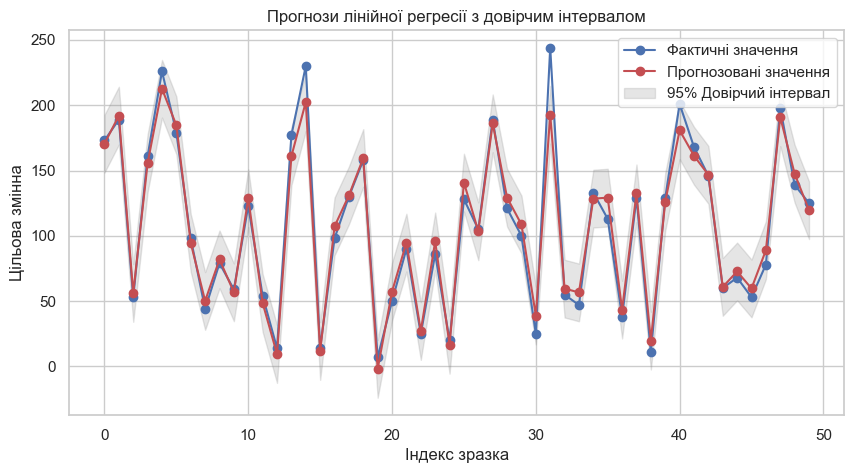

In [9]:
# Візуалізація прогнозів лінійної регресії з довірчими інтервалами для перших 50 зразків
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], 'bo-', label='Фактичні значення')
plt.plot(y_pred_lr[:50], 'ro-', label='Прогнозовані значення')
plt.fill_between(np.arange(50), 
                 pred_summary['obs_ci_lower'][:50], 
                 pred_summary['obs_ci_upper'][:50], 
                 color='gray', alpha=0.2, label='95% Довірчий інтервал')
plt.legend()
plt.xlabel('Індекс зразка')
plt.ylabel('Цільова змінна')
plt.title('Прогнози лінійної регресії з довірчим інтервалом')
plt.show()


Gradient Boosting - MAE: 2.606, RMSE: 3.615, R²: 0.997
   Actual   Predicted  Lower Bound  Upper Bound
0   173.0  170.392495   114.056477   177.044456
1   189.0  193.559526   106.440347   203.651723
2    53.0   50.901286    45.537845    55.987721
3   161.0  163.205565   110.726001   168.728784
4   226.0  223.256632   114.056477   229.196521
5   179.0  180.552255   111.881959   201.727534
6    98.0   96.084023    70.339963    96.435080
7    44.0   43.496494    39.737185    49.497001
8    79.0   79.738852    74.249605    95.993875
9    59.0   57.412830    54.029557    67.388116


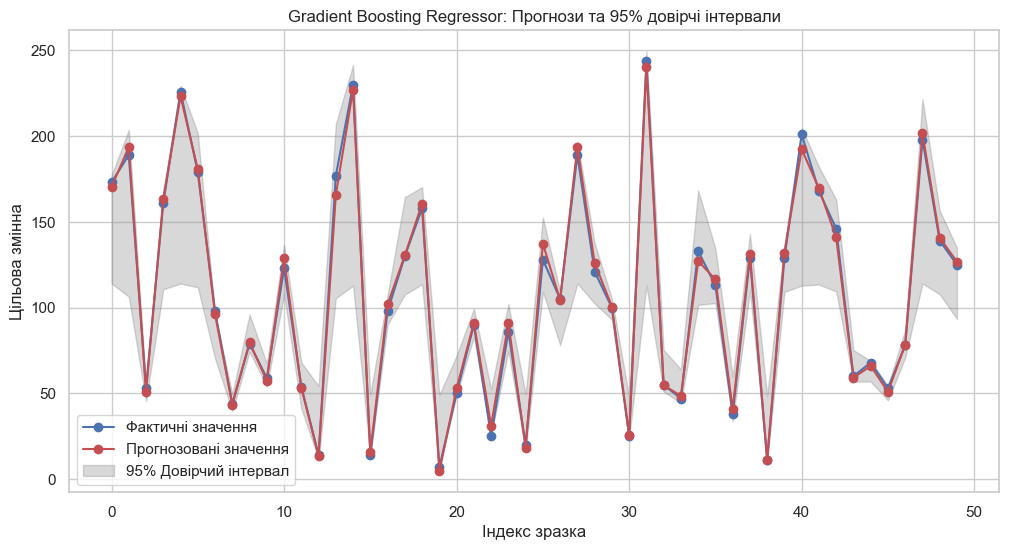

In [10]:
# Gradient Boosting Regressor (базова модель)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print("Gradient Boosting - MAE: {:.3f}, RMSE: {:.3f}, R²: {:.3f}".format(mae_gb, rmse_gb, r2_gb))
# Обчислення довірчих інтервалів за допомогою квантильного градієнтного бустингу
# Навчаємо дві додаткові моделі для нижньої та верхньої меж (95% довірчий інтервал)

# Модель для нижньої межі (2.5-й процентиль)
gb_lower = GradientBoostingRegressor(loss='quantile', alpha=0.025, n_estimators=100, learning_rate=0.1, random_state=42)
gb_lower.fit(X_train_scaled, y_train)
y_pred_lower = gb_lower.predict(X_test_scaled)

# Модель для верхньої межі (97.5-й процентиль)
gb_upper = GradientBoostingRegressor(loss='quantile', alpha=0.975, n_estimators=100, learning_rate=0.1, random_state=42)
gb_upper.fit(X_train_scaled, y_train)
y_pred_upper = gb_upper.predict(X_test_scaled)

# Виведемо декілька прикладів прогнозів з довірчими інтервалами
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_gb,
    'Lower Bound': y_pred_lower,
    'Upper Bound': y_pred_upper
})
print(results.head(10))
# Візуалізація прогнозів та довірчих інтервалів для перших 50 зразків
plt.figure(figsize=(12,6))
indices = np.arange(50)
plt.plot(indices, y_test.values[:50], 'bo-', label='Фактичні значення')
plt.plot(indices, y_pred_gb[:50], 'ro-', label='Прогнозовані значення')
plt.fill_between(indices, y_pred_lower[:50], y_pred_upper[:50], color='gray', alpha=0.3, label='95% Довірчий інтервал')
plt.xlabel('Індекс зразка')
plt.ylabel('Цільова змінна')
plt.title('Gradient Boosting Regressor: Прогнози та 95% довірчі інтервали')
plt.legend()
plt.show()


Random Forest - MAE: 1.815, RMSE: 2.830, R²: 0.998
   Actual  Predicted  Min Prediction  Max Prediction
0   173.0     170.65           151.0           186.0
1   189.0     193.66           168.0           220.0
2    53.0      53.27            50.0            60.0
3   161.0     159.78           144.0           180.0
4   226.0     220.43           205.0           240.0
5   179.0     178.11           160.0           201.0
6    98.0      96.62            83.0           115.0
7    44.0      45.80            40.0            55.0
8    79.0      80.09            73.0            88.0
9    59.0      58.91            54.0            65.0


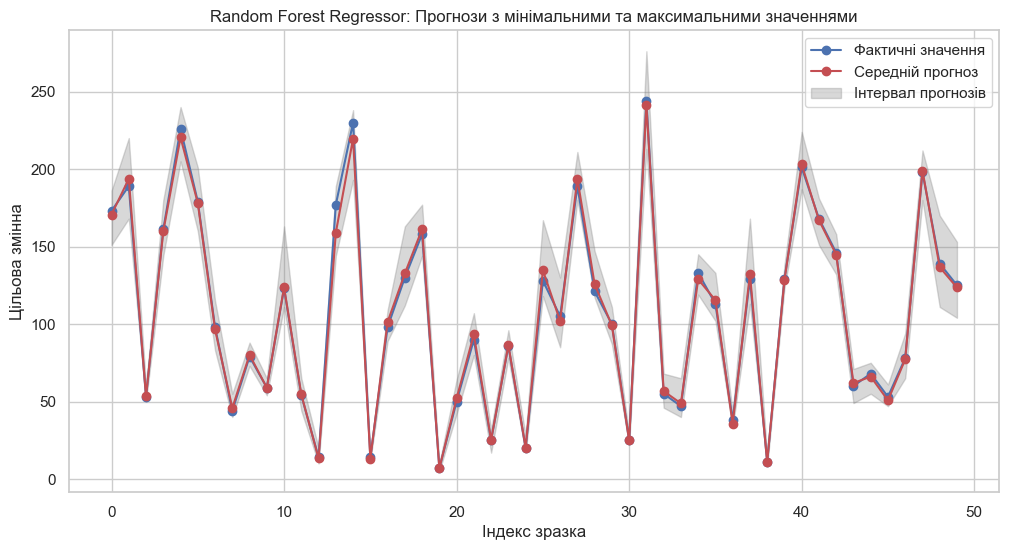

In [21]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest - MAE: {:.3f}, RMSE: {:.3f}, R²: {:.3f}".format(mae_rf, rmse_rf, r2_rf))

# ---------------------------------------------------------
# Отримуємо прогнози окремих дерев для кожного зразка
# rf_model.estimators_ містить окремі дерева
tree_preds = np.array([tree.predict(X_test_scaled) for tree in rf_model.estimators_]).T

# Для кожного зразка знаходимо мінімальне та максимальне значення прогнозів
y_pred_min = tree_preds.min(axis=1)
y_pred_max = tree_preds.max(axis=1)

# Створимо DataFrame для порівняння: фактичні значення, середній прогноз, нижня та верхня межа прогнозу
results_rf = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf,
    'Min Prediction': y_pred_min,
    'Max Prediction': y_pred_max
})
print(results_rf.head(10))

# ---------------------------------------------------------
# Візуалізація прогнозів із мінімальними та максимальними значеннями для перших 50 зразків
plt.figure(figsize=(12,6))
indices = np.arange(50)
plt.plot(indices, y_test.values[:50], 'bo-', label='Фактичні значення')
plt.plot(indices, y_pred_rf[:50], 'ro-', label='Середній прогноз')
plt.fill_between(indices, y_pred_min[:50], y_pred_max[:50], color='gray', alpha=0.3, label='Інтервал прогнозів')
plt.xlabel('Індекс зразка')
plt.ylabel('Цільова змінна')
plt.title('Random Forest Regressor: Прогнози з мінімальними та максимальними значеннями')
plt.legend()
plt.show()


In [22]:
# Використовуємо KBinsDiscretizer для рівномірного розбиття (наприклад, на 4 класи)
n_bins = 4
kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
y_train_class = kbd.fit_transform(y_train.values.reshape(-1, 1)).astype(int).ravel()
y_test_class = kbd.transform(y_test.values.reshape(-1, 1)).astype(int).ravel()

print("Розподіл класів у тренувальних даних:\n", pd.Series(y_train_class).value_counts())

Розподіл класів у тренувальних даних:
 0    6072
1    3867
2    1936
3     125
Name: count, dtype: int64


In [23]:
# Побудова класифікаційних моделей
# Логістична регресія
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train_class)
y_pred_logreg = logreg.predict(X_test_scaled)

# Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_scaled, y_train_class)
y_pred_dtc = dtc.predict(X_test_scaled)

# XGBoost Classifier
xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_clf.fit(X_train_scaled, y_train_class)
y_pred_xgb = xgb_clf.predict(X_test_scaled)

In [24]:
# Функція для оцінки якості класифікації
def print_classification_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{model_name} - Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1-score: {f1:.3f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))


print_classification_metrics(y_test_class, y_pred_logreg, "Логістична регресія")
print_classification_metrics(y_test_class, y_pred_dtc, "Decision Tree")
print_classification_metrics(y_test_class, y_pred_xgb, "XGBoost")

Логістична регресія - Accuracy: 0.956, Precision: 0.956, Recall: 0.956, F1-score: 0.956
Confusion Matrix:
[[1430   33    0    0]
 [  31  912   35    0]
 [   0   20  499    1]
 [   0    0   12   27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1463
           1       0.95      0.93      0.94       978
           2       0.91      0.96      0.94       520
           3       0.96      0.69      0.81        39

    accuracy                           0.96      3000
   macro avg       0.95      0.89      0.91      3000
weighted avg       0.96      0.96      0.96      3000

Decision Tree - Accuracy: 0.954, Precision: 0.954, Recall: 0.954, F1-score: 0.954
Confusion Matrix:
[[1436   27    0    0]
 [  23  922   33    0]
 [   0   30  479   11]
 [   0    0   13   26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1463
           1  

In [25]:
n_bins_alt = 6
kbd_alt = KBinsDiscretizer(n_bins=n_bins_alt, encode='ordinal', strategy='uniform')
y_train_class_alt = kbd_alt.fit_transform(y_train.values.reshape(-1, 1)).astype(int).ravel()
y_test_class_alt = kbd_alt.transform(y_test.values.reshape(-1, 1)).astype(int).ravel()

print("Розподіл класів (6 класів) у тренувальних даних:\n", pd.Series(y_train_class_alt).value_counts())

# Перенавчання моделей на нових класах
logreg_alt = LogisticRegression(max_iter=1000, random_state=42)
logreg_alt.fit(X_train_scaled, y_train_class_alt)
y_pred_logreg_alt = logreg_alt.predict(X_test_scaled)
print_classification_metrics(y_test_class_alt, y_pred_logreg_alt, "Логістична регресія (6 класів)")


Розподіл класів (6 класів) у тренувальних даних:
 0    4362
1    3112
2    2465
3    1650
4     385
5      26
Name: count, dtype: int64
Логістична регресія (6 класів) - Accuracy: 0.928, Precision: 0.927, Recall: 0.928, F1-score: 0.926
Confusion Matrix:
[[1041   26    0    0    0    0]
 [  27  707   31    0    0    0]
 [   0   35  540   34    0    0]
 [   0    0   21  413    2    1]
 [   0    0    0   34   82    0]
 [   0    0    0    0    6    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      1067
           1       0.92      0.92      0.92       765
           2       0.91      0.89      0.90       609
           3       0.86      0.95      0.90       437
           4       0.91      0.71      0.80       116
           5       0.00      0.00      0.00         6

    accuracy                           0.93      3000
   macro avg       0.76      0.74      0.75      3000
weighted avg       0.93      0.93  

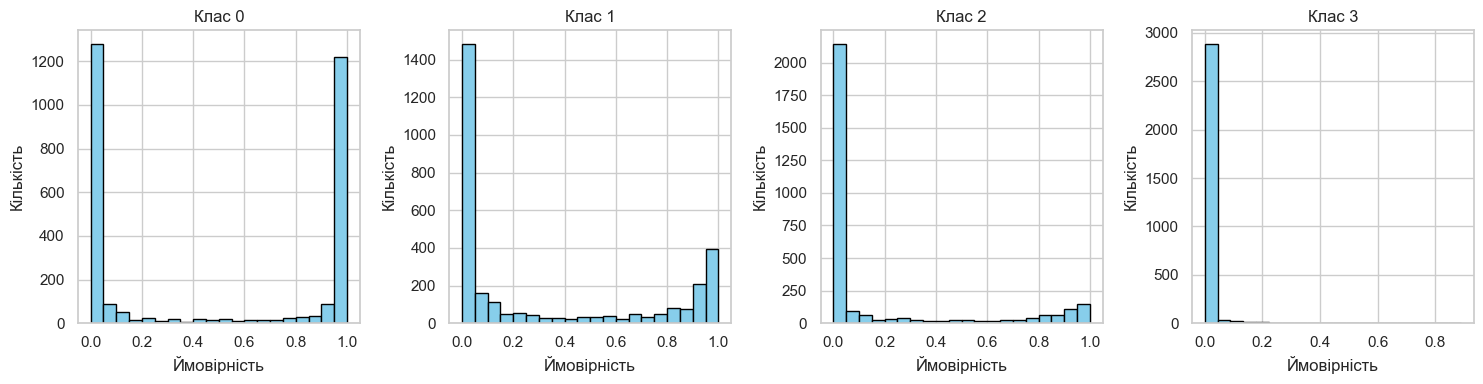

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Навчаємо Random Forest для класифікації (на попередньо отриманих класах з 4 класів)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train_class)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)

# Для кожного класу побудуємо гістограму передбачуваних ймовірностей
plt.figure(figsize=(15, 4))
for i in range(n_bins):
    plt.subplot(1, n_bins, i+1)
    plt.hist(y_proba_rf[:, i], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Клас {i}")
    plt.xlabel("Ймовірність")
    plt.ylabel("Кількість")
plt.tight_layout()
plt.show()


# Аналіз розподілу ймовірностей може показати, як модель впевнено/невпевнено класифікує зразки.
# При overfitting часто спостерігається надмірна впевненість (ймовірності близькі до 0 або 1),
# тоді як при underfitting розподіл буде більш рівномірним.


In [27]:
# Підбираємо параметри для Decision Tree
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_class)
print("Найкращі параметри для Decision Tree:", grid_search.best_params_)

# Оцінка оптимізованої моделі
dtc_opt = grid_search.best_estimator_
y_pred_dtc_opt = dtc_opt.predict(X_test_scaled)
print_classification_metrics(y_test_class, y_pred_dtc_opt, "Оптимізований Decision Tree")


Найкращі параметри для Decision Tree: {'max_depth': None, 'min_samples_split': 5}
Оптимізований Decision Tree - Accuracy: 0.953, Precision: 0.953, Recall: 0.953, F1-score: 0.953
Confusion Matrix:
[[1435   28    0    0]
 [  25  920   33    0]
 [   0   32  477   11]
 [   0    0   13   26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1463
           1       0.94      0.94      0.94       978
           2       0.91      0.92      0.91       520
           3       0.70      0.67      0.68        39

    accuracy                           0.95      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.95      0.95      0.95      3000



In [28]:
# Порівняння регресії та класифікації
print("Порівняння:")
print("Регресійна задача регресії (наприклад, Random Forest): RMSE = {:.3f}".format(rmse_rf))
print("Класифікаційна задача (оптимізований Decision Tree): Accuracy = {:.3f}".format(accuracy_score(y_test_class, y_pred_dtc_opt)))


# Висновки:
# - Порівнюючи результати, можна визначити, чи дає дискретизація цільової змінної (класифікація)
#   кращі результати, чи ж регресія є більш інформативною.
# - Розподіл ймовірностей показав, як модель впевнено робить прогнози.
# - Ансамблеві підходи (Stacking, Random Forest, Gradient Boosting) здатні покращити результати за відповідними метриками.



Порівняння:
Регресійна задача регресії (наприклад, Random Forest): RMSE = 2.830
Класифікаційна задача (оптимізований Decision Tree): Accuracy = 0.953


In [29]:
# Порівняння регресії та класифікації

print("=== Порівняння ===")
print("Регресійна задача (Random Forest):")
print("  RMSE = {:.3f}".format(rmse_rf))
print("  MAE  = {:.3f}".format(mae_rf))
print("")
print("Класифікаційна задача (Оптимізований Decision Tree):")
acc_clf = accuracy_score(y_test_class, y_pred_dtc_opt)
print("  Accuracy = {:.3f}".format(acc_clf))

# Обчислюємо ширину класу (w) та розмах цільової змінної (R)
# Для дискретизації використовувалось n_bins = 4
n_bins = 4
y_min, y_max = y_test.min(), y_test.max()
R = y_max - y_min          # розмах цільової змінної
w = R / n_bins             # ширина кожного класу

# 1. Перетворення MAE регресії у точність класифікації:
# Формула: accuracy ≈ 1 - (MAE / w)
acc_from_mae = 1 - (mae_rf / w)

# 2. Перетворення точності класифікації у MAE:
# Формула: MAE ≈ (1 - accuracy)*R + (w / 2)
mae_from_acc = (1 - acc_clf) * R + (w / 2)

print("\n=== Перетворення за формулами ===")
print("З MAE регресії ({:.3f}) отримуємо приблизну точність: {:.3f}".format(mae_rf, acc_from_mae))
print("   (Формула: accuracy ≈ 1 - MAE/w, де w = {:.2f})".format(w))
print("")
print("З точності класифікації ({:.3f}) отримуємо приблизну MAE: {:.3f}".format(acc_clf, mae_from_acc))
print("   (Формула: MAE ≈ (1 - accuracy)*R + w/2, де R = {:.2f}, w = {:.2f})".format(R, w))


=== Порівняння ===
Регресійна задача (Random Forest):
  RMSE = 2.830
  MAE  = 1.815

Класифікаційна задача (Оптимізований Decision Tree):
  Accuracy = 0.953

=== Перетворення за формулами ===
З MAE регресії (1.815) отримуємо приблизну точність: 0.975
   (Формула: accuracy ≈ 1 - MAE/w, де w = 73.50)

З точності класифікації (0.953) отримуємо приблизну MAE: 50.666
   (Формула: MAE ≈ (1 - accuracy)*R + w/2, де R = 294.00, w = 73.50)


Точність дискретизованих прогнозів регресії = 0.984
MAE для регресії після заміни дискретизованих прогнозів середніми значеннями класів = 18.91504225372591


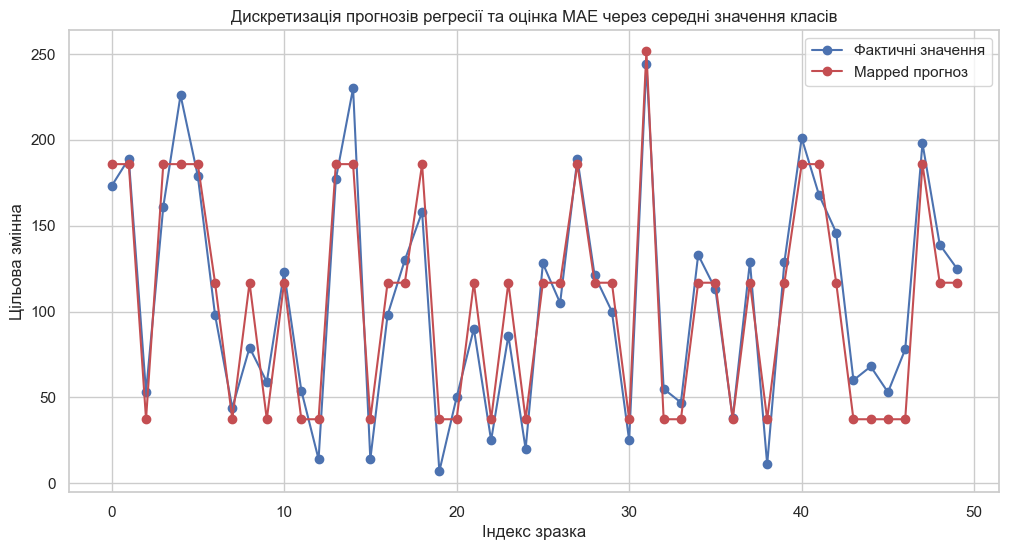

In [30]:
# Використовуємо KBinsDiscretizer, який застосовувався для формування класів (наприклад, n_bins = 4)
# Дискретизуємо регресійні прогнозування з Random Forest
reg_pred_class = kbd.transform(y_pred_rf.reshape(-1, 1)).astype(int).ravel()

# Обчислюємо точність дискретизованих прогнозів порівняно з фактичними класами
accuracy_reg_pred = accuracy_score(y_test_class, reg_pred_class)
print("Точність дискретизованих прогнозів регресії =", accuracy_reg_pred)

# ----- Оцінка MAE через середні значення класів -----

# Обчислюємо середнє значення цільової змінної для кожного класу (на тренувальних даних)
# y_train_class вже отриманий раніше при дискретизації y_train
class_means = {}
for cls in range(n_bins):
    # Якщо у класі є спостереження, обчислюємо середнє; інакше використовуємо середину інтервалу
    cls_vals = y_train[y_train_class == cls]
    if len(cls_vals) > 0:
        class_means[cls] = cls_vals.mean()
    else:
        # Визначаємо середину інтервалу для цього класу
        bin_edges = kbd.bin_edges_[0]
        class_means[cls] = (bin_edges[cls] + bin_edges[cls+1]) / 2

# Замапуємо дискретизовані прогнозування у середні значення відповідних класів
mapped_reg_pred = np.array([class_means[cls] for cls in reg_pred_class])

# Обчислюємо MAE між замапованими прогнозами та фактичними значеннями
mae_mapped = np.mean(np.abs(y_test.values - mapped_reg_pred))
print("MAE для регресії після заміни дискретизованих прогнозів середніми значеннями класів =", mae_mapped)

# Візуалізація: порівняння фактичних значень та "mapped" прогнозів для перших 50 зразків
plt.figure(figsize=(12,6))
indices = np.arange(50)
plt.plot(indices, y_test.values[:50], 'bo-', label='Фактичні значення')
plt.plot(indices, mapped_reg_pred[:50], 'ro-', label='Mapped прогноз')
plt.xlabel('Індекс зразка')
plt.ylabel('Цільова змінна')
plt.title('Дискретизація прогнозів регресії та оцінка MAE через середні значення класів')
plt.legend()
plt.show()